In [2]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")



In [4]:
df = pd.read_excel("../datasets/carrot_complete_growth_dataset.xlsx")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.head()

 

,Date,Carrot_Avg_Price,Carrot_Min_Price,Carrot_Max_Price,Labour Cost,Transportation Cost,Fertilizer (Urea),Fertilizer(MOP),Plantation Crop,Average of tempmax_avg_75d,Average of dew_avg_75d,Average of tempmin_avg_75d,Average of temp_avg_75d,Average of windspeed_avg_75d,Average of precip_avg_75d,Average of humidity_avg_75d,Average of cloudcover_avg_75d,Average of solarradiation_avg_75d,Average of windgust_avg_75d,Average of solarenergy_avg_75d
0,2020-06-15,100.00 - 130.00,100,130,500,4160,180,300,1000,29.560746,19.703947,15.954167,23.262500,14.764912,6.522357,81.799781,67.789693,232.072149,32.972588,20.062939
1,2020-06-16,100.00 - 120.00,100,120,500,4160,180,300,1000,29.564693,19.762061,15.990789,23.277193,14.732456,6.523658,81.956360,67.951096,231.635307,33.113816,20.024781
2,2020-06-17,100.00 - 130.00,100,130,500,4160,180,300,1000,29.559430,19.836842,16.014912,23.295175,14.854386,6.538441,82.179825,68.410307,230.398026,33.246711,19.917982
3,2020-06-18,90.00 - 120.00,90,120,500,4160,180,300,1000,29.558553,19.868202,16.049781,23.313596,15.001316,6.538781,82.225000,68.973465,229.512061,33.292982,19.842325
4,2020-06-19,70.00 - 100.00,70,100,500,4160,180,300,1000,29.588816,19.871711,16.069518,23.343202,15.048465,6.503066,82.108333,69.005921,229.419956,33.393421,19.834868


In [8]:
df = df.rename(columns={
    "Carrot_Min_Price": "Min_Price",
    "Carrot_Max_Price": "Max_Price",
    "Carrot_Avg_Price": "Avg_Price",
    "Labour Cost": "Labour_Cost",
    "Transportation Cost": "Transport_Cost",
    "Fertilizer (Urea)": "Fertilizer_Urea",
    "Fertilizer(MOP)": "Fertilizer_MOP",
    "Plantation Crop": "Plantation_Cost"
})

df.columns

Index(['Date', 'Avg_Price', 'Min_Price', 'Max_Price', 'Labour_Cost',
       'Transport_Cost', 'Fertilizer_Urea', 'Fertilizer_MOP',
       'Plantation_Cost', 'Average of tempmax_avg_75d',
       'Average of dew_avg_75d', 'Average of tempmin_avg_75d',
       'Average of temp_avg_75d', 'Average of windspeed_avg_75d',
       'Average of precip_avg_75d', 'Average of humidity_avg_75d',
       'Average of cloudcover_avg_75d', 'Average of solarradiation_avg_75d',
       'Average of windgust_avg_75d', 'Average of solarenergy_avg_75d'],
      dtype='object')

In [9]:
df["price_min_lag1"] = df["Min_Price"].shift(1)
df["price_min_lag3"] = df["Min_Price"].shift(3)
df["price_min_lag7"] = df["Min_Price"].shift(7)

df["price_max_lag1"] = df["Max_Price"].shift(1)
df["price_max_lag3"] = df["Max_Price"].shift(3)
df["price_max_lag7"] = df["Max_Price"].shift(7)

df = df.dropna().reset_index(drop=True)

df.head()



,Date,Avg_Price,Min_Price,Max_Price,Labour_Cost,Transport_Cost,Fertilizer_Urea,Fertilizer_MOP,Plantation_Cost,Average of tempmax_avg_75d,...,Average of cloudcover_avg_75d,Average of solarradiation_avg_75d,Average of windgust_avg_75d,Average of solarenergy_avg_75d,price_min_lag1,price_min_lag3,price_min_lag7,price_max_lag1,price_max_lag3,price_max_lag7
0,2020-06-24,110.00 - 150.00,110,150,500,4160,180,300,1000,29.586842,...,72.176754,224.736184,34.050439,19.435526,120.0,70.0,100.0,140.0,100.0,130.0
1,2020-06-25,120.00 - 150.00,120,150,500,4160,180,300,1000,29.572588,...,72.910965,222.888158,34.039474,19.275658,110.0,80.0,100.0,150.0,120.0,120.0
2,2020-06-26,100.00 - 130.0,100,130,500,4160,180,300,1000,29.553947,...,73.426096,221.883991,34.266009,19.188816,120.0,120.0,100.0,150.0,140.0,130.0
3,2020-06-29,100.00 - 140.00,100,140,500,4160,180,300,1000,29.596930,...,73.987061,221.292105,34.602193,19.138158,100.0,110.0,90.0,130.0,150.0,120.0
4,2020-06-30,90.00 - 130.00,90,130,500,4160,180,300,1000,29.605921,...,74.411184,220.615789,34.678728,19.079167,100.0,120.0,70.0,140.0,150.0,100.0


In [10]:
features = [
    "price_min_lag1", "price_min_lag3", "price_min_lag7",
    "price_max_lag1", "price_max_lag3", "price_max_lag7",
    "Labour_Cost", "Transport_Cost", "Fertilizer_Urea",
    "Fertilizer_MOP", "Plantation_Cost"
]

X = df[features]

y_min = df["Min_Price"]
y_max = df["Max_Price"]


In [12]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_min_train = y_min.iloc[:split_index]
y_min_test  = y_min.iloc[split_index:]

y_max_train = y_max.iloc[:split_index]
y_max_test  = y_max.iloc[split_index:]


In [13]:
from sklearn.linear_model import LinearRegression

lr_min = LinearRegression()
lr_max = LinearRegression()

lr_min.fit(X_train, y_min_train)
lr_max.fit(X_train, y_max_train)

pred_min_lr = lr_min.predict(X_test)
pred_max_lr = lr_max.predict(X_test)


In [14]:
from sklearn.ensemble import RandomForestRegressor

rf_min = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_max = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_min.fit(X_train, y_min_train)
rf_max.fit(X_train, y_max_train)

pred_min_rf = rf_min.predict(X_test)
pred_max_rf = rf_max.predict(X_test)


In [15]:
from xgboost import XGBRegressor

xgb_min = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_max = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_min.fit(X_train, y_min_train)
xgb_max.fit(X_train, y_max_train)

pred_min_xgb = xgb_min.predict(X_test)
pred_max_xgb = xgb_max.predict(X_test)


In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse


In [17]:
results = []

models = {
    "Linear Regression": (pred_min_lr, pred_max_lr),
    "Random Forest": (pred_min_rf, pred_max_rf),
    "XGBoost": (pred_min_xgb, pred_max_xgb)
}

for model, (pmin, pmax) in models.items():
    mae_min, rmse_min = evaluate_model(y_min_test, pmin)
    mae_max, rmse_max = evaluate_model(y_max_test, pmax)
    
    results.append([
        model,
        mae_min, rmse_min,
        mae_max, rmse_max
    ])

results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE (Min)", "RMSE (Min)", "MAE (Max)", "RMSE (Max)"]
)

results_df


,Model,MAE (Min),RMSE (Min),MAE (Max),RMSE (Max)
0,Linear Regression,22.092714,31.115348,22.196267,32.353277
1,Random Forest,22.708661,31.958423,24.001527,32.949187
2,XGBoost,25.431479,33.533755,27.624189,35.394726


In [18]:
from sklearn.metrics import r2_score
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2


In [19]:
results = []

models = {
    "Linear Regression": (pred_min_lr, pred_max_lr),
    "Random Forest": (pred_min_rf, pred_max_rf),
    "XGBoost": (pred_min_xgb, pred_max_xgb)
}

for model, (pmin, pmax) in models.items():
    mae_min, rmse_min, r2_min = evaluate_model(y_min_test, pmin)
    mae_max, rmse_max, r2_max = evaluate_model(y_max_test, pmax)
    
    results.append([
        model,
        mae_min, rmse_min, r2_min,
        mae_max, rmse_max, r2_max
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE (Min)", "RMSE (Min)", "R² (Min)",
        "MAE (Max)", "RMSE (Max)", "R² (Max)"
    ]
)

results_df


,Model,MAE (Min),RMSE (Min),R² (Min),MAE (Max),RMSE (Max),R² (Max)
0,Linear Regression,22.092714,31.115348,0.882121,22.196267,32.353277,0.899241
1,Random Forest,22.708661,31.958423,0.875646,24.001527,32.949187,0.895495
2,XGBoost,25.431479,33.533755,0.863085,27.624189,35.394726,0.879406


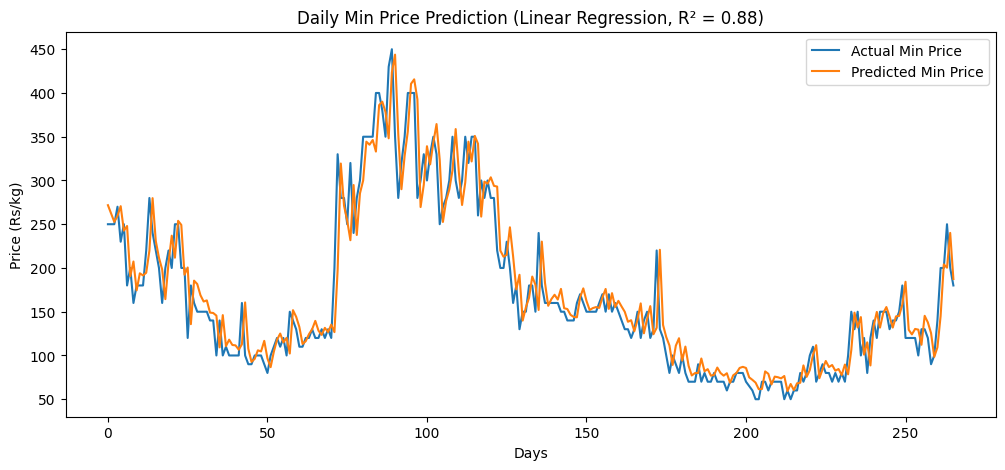

In [20]:
best_pred = pred_min_lr  # Linear Regression performed best

plt.figure(figsize=(12,5))
plt.plot(y_min_test.values, label="Actual Min Price")
plt.plot(best_pred, label="Predicted Min Price")
plt.title("Daily Min Price Prediction (Linear Regression, R² = 0.88)")
plt.xlabel("Days")
plt.ylabel("Price (Rs/kg)")
plt.legend()
plt.show()


In [21]:
best_min_model = lr_min
best_max_model = lr_max

In [22]:
last_row = df.iloc[-1].copy()
last_row


Date                                 2024-12-31 00:00:00
Avg_Price                                      180 - 250
Min_Price                                            180
Max_Price                                            250
Labour_Cost                                         1300
Transport_Cost                                     11320
Fertilizer_Urea                                      180
Fertilizer_MOP                                       300
Plantation_Cost                                     1000
Average of tempmax_avg_75d                     27.248158
Average of dew_avg_75d                         20.312105
Average of tempmin_avg_75d                     17.974474
Average of temp_avg_75d                        22.653684
Average of windspeed_avg_75d                   10.412632
Average of precip_avg_75d                       9.666713
Average of humidity_avg_75d                    87.669474
Average of cloudcover_avg_75d                  74.283421
Average of solarradiation_avg_7

In [27]:
import pandas as pd

jan_dates = pd.date_range(start="2026-01-01", end="2026-02-28", freq="D")
jan_dates


DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
               '2026-01-09', '2026-01-10', '2026-01-11', '2026-01-12',
               '2026-01-13', '2026-01-14', '2026-01-15', '2026-01-16',
               '2026-01-17', '2026-01-18', '2026-01-19', '2026-01-20',
               '2026-01-21', '2026-01-22', '2026-01-23', '2026-01-24',
               '2026-01-25', '2026-01-26', '2026-01-27', '2026-01-28',
               '2026-01-29', '2026-01-30', '2026-01-31', '2026-02-01',
               '2026-02-02', '2026-02-03', '2026-02-04', '2026-02-05',
               '2026-02-06', '2026-02-07', '2026-02-08', '2026-02-09',
               '2026-02-10', '2026-02-11', '2026-02-12', '2026-02-13',
               '2026-02-14', '2026-02-15', '2026-02-16', '2026-02-17',
               '2026-02-18', '2026-02-19', '2026-02-20', '2026-02-21',
               '2026-02-22', '2026-02-23', '2026-02-24', '2026-02-25',
      

In [28]:
jan_predictions = []

# Keep last known prices
prev_min = last_row["Min_Price"]
prev_max = last_row["Max_Price"]

for date in jan_dates:
    
    X_future = pd.DataFrame([{
        "price_min_lag1": prev_min,
        "price_min_lag3": prev_min,   # simplified assumption
        "price_min_lag7": prev_min,
        "price_max_lag1": prev_max,
        "price_max_lag3": prev_max,
        "price_max_lag7": prev_max,
        "Labour_Cost": last_row["Labour_Cost"],
        "Transport_Cost": last_row["Transport_Cost"],
        "Fertilizer_Urea": last_row["Fertilizer_Urea"],
        "Fertilizer_MOP": last_row["Fertilizer_MOP"],
        "Plantation_Cost": last_row["Plantation_Cost"]
    }])
    
    pred_min = best_min_model.predict(X_future)[0]
    pred_max = best_max_model.predict(X_future)[0]
    
    jan_predictions.append([date, pred_min, pred_max])
    
    # Update for next day
    prev_min = pred_min
    prev_max = pred_max


In [29]:
jan_df = pd.DataFrame(
    jan_predictions,
    columns=["Date", "Predicted_Min_Price", "Predicted_Max_Price"]
)

jan_df.head(60)


,Date,Predicted_Min_Price,Predicted_Max_Price
0,2026-01-01,182.418945,240.660872
1,2026-01-02,185.821605,237.279768
2,2026-01-03,189.772092,237.564610
3,2026-01-04,193.997847,240.070787
4,2026-01-05,198.329417,243.889108
5,2026-01-06,202.662399,248.448604
6,2026-01-07,206.933393,253.391911
7,2026-01-08,211.104809,258.496518
8,2026-01-09,215.155274,263.625008
9,2026-01-10,219.073565,268.693612


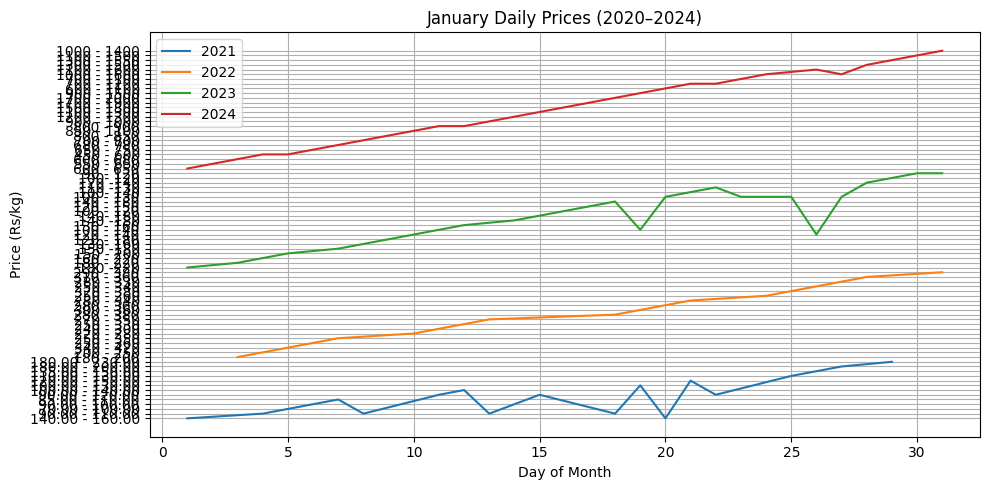

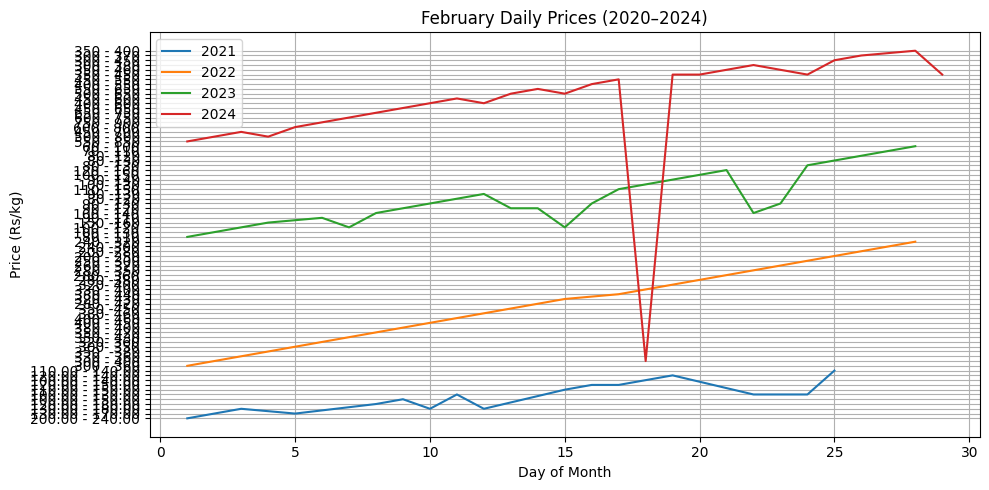

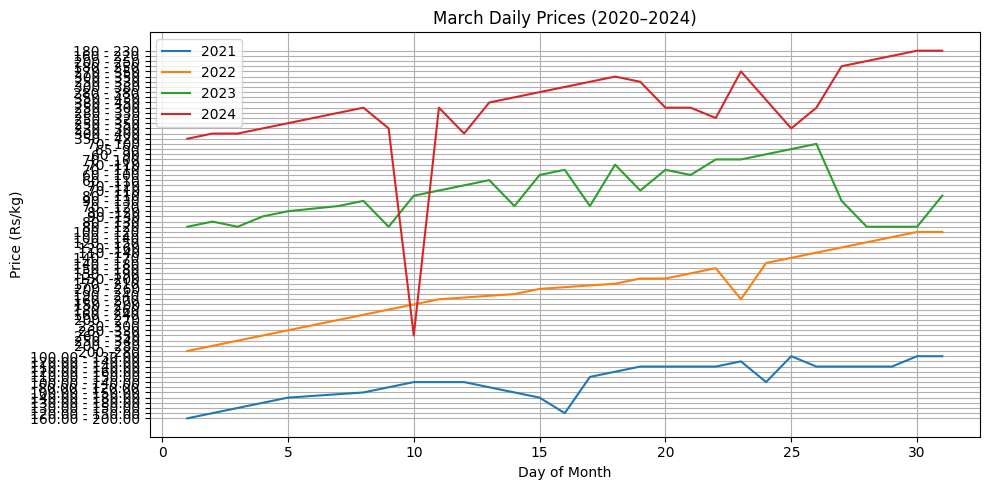

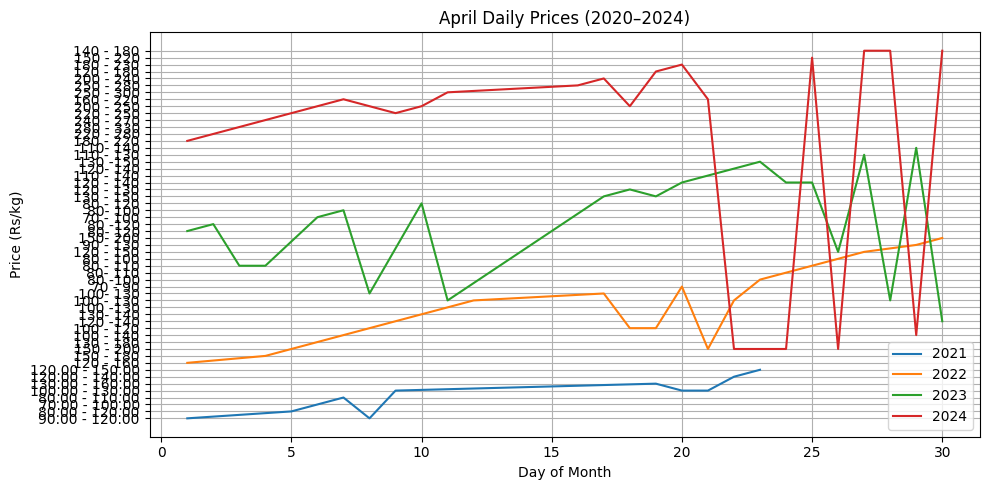

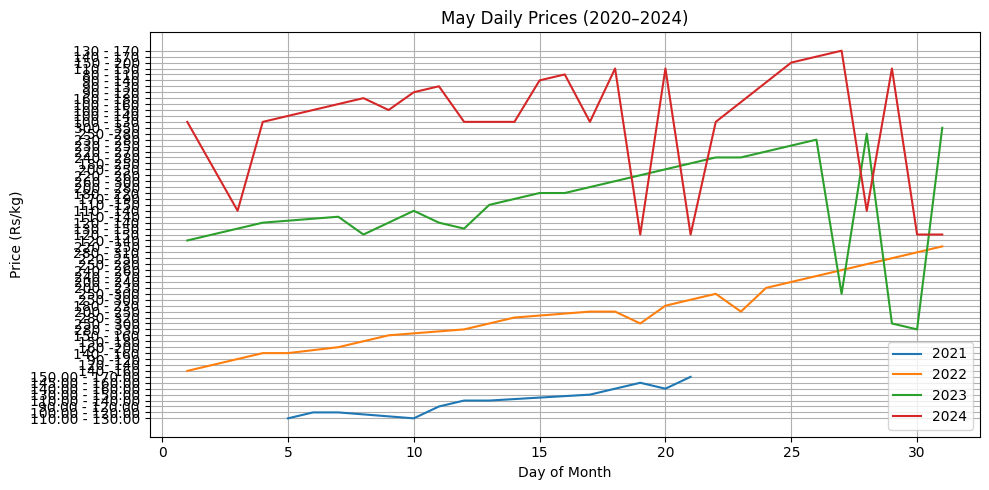

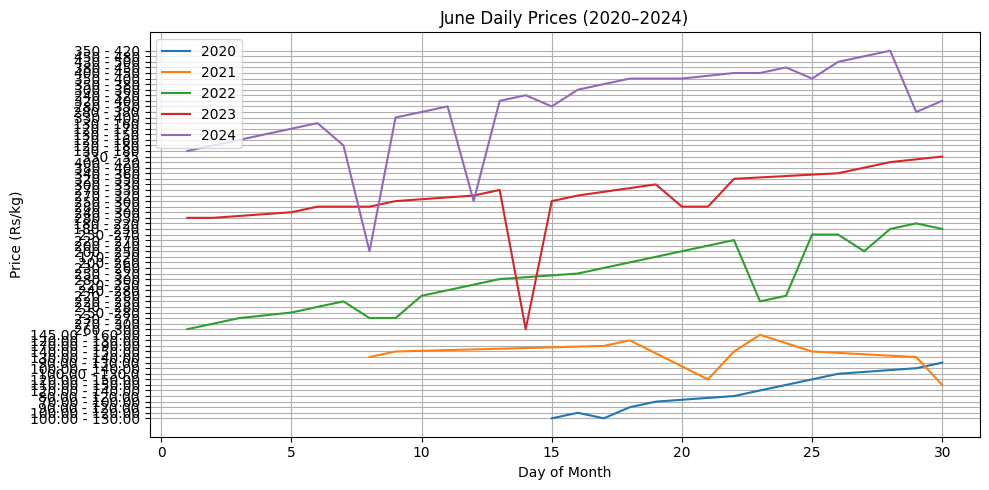

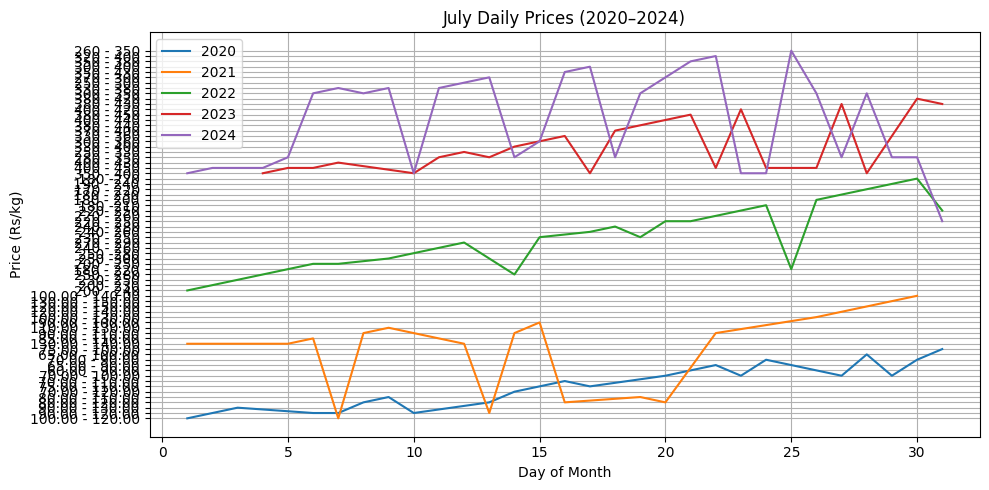

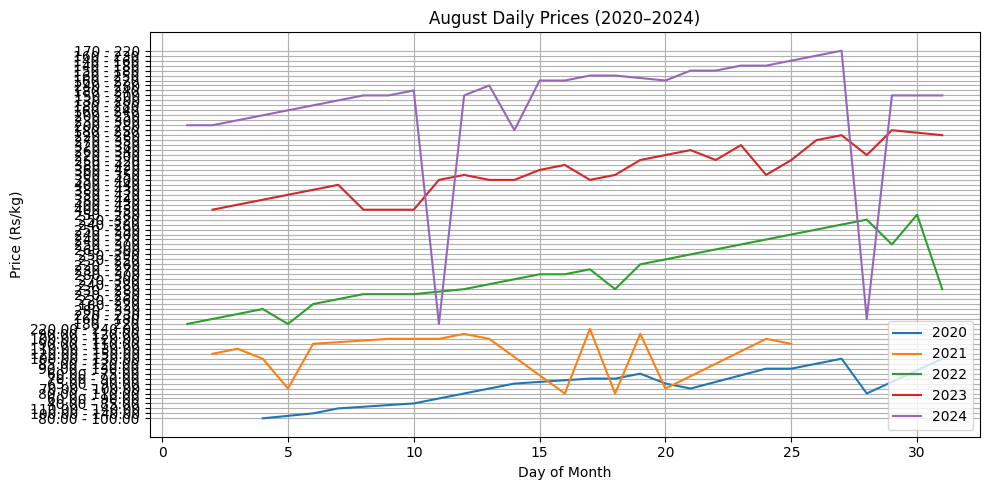

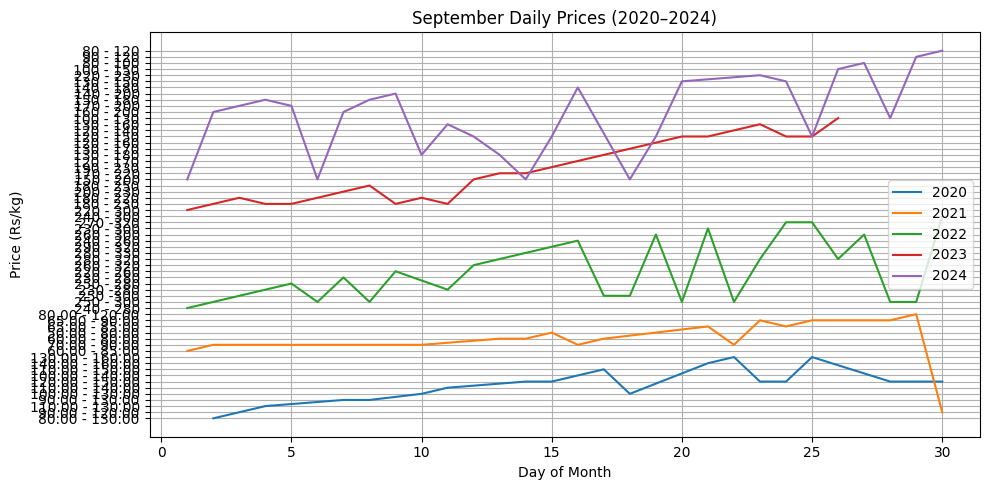

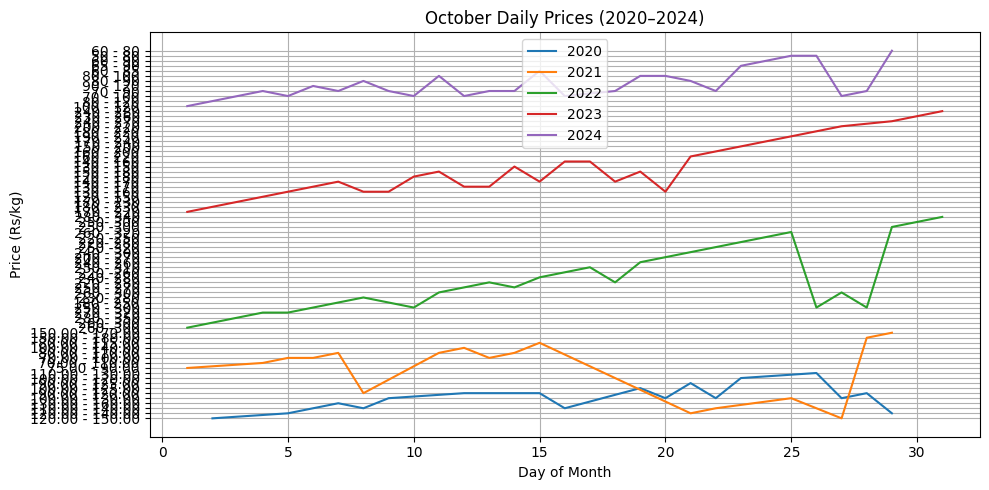

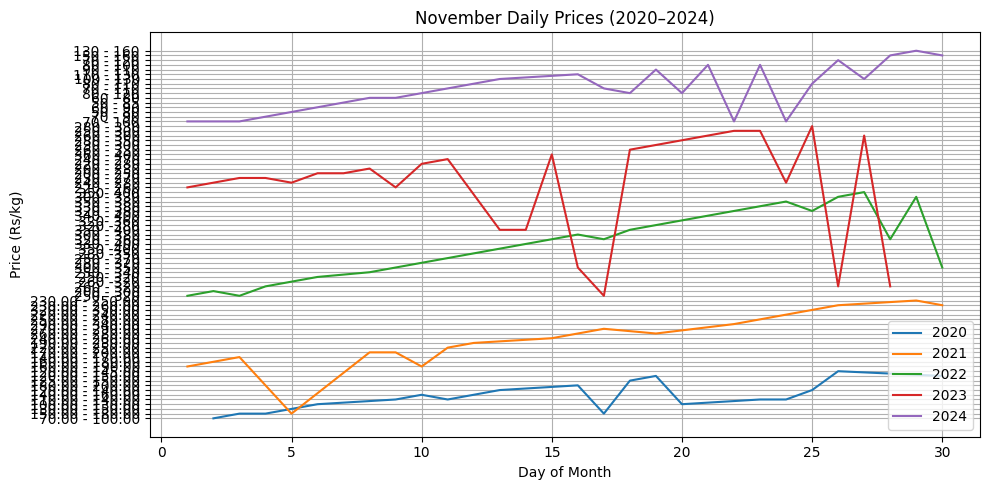

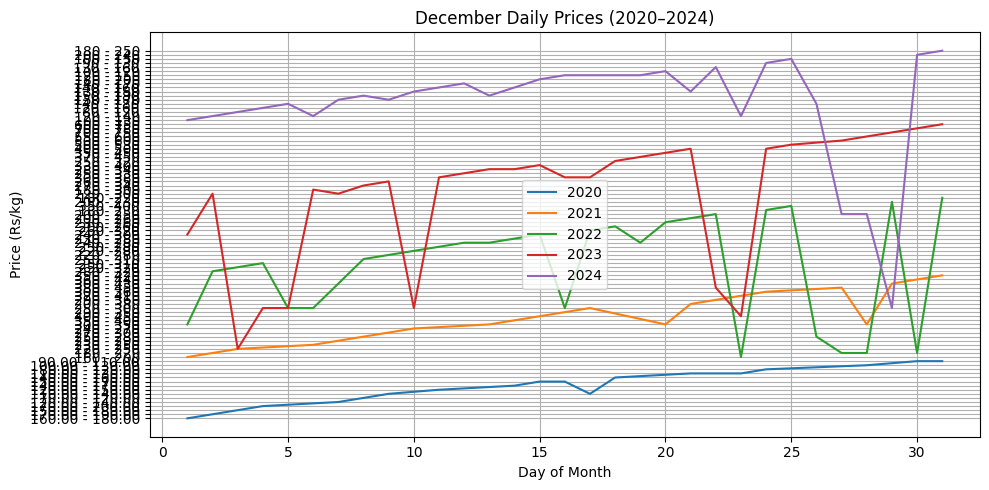

In [30]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt


# ==============================
# 2. LOAD DATASET
# ==============================
# CHANGE PATH IF NEEDED
df = pd.read_excel("../datasets/carrot_complete_growth_dataset.xlsx")

# ==============================
# 3. DATE PROCESSING
# ==============================
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day


# ==============================
# 4. RENAME PRICE COLUMN
# ==============================
df = df.rename(columns={
    "Carrot_Avg_Price": "Avg_Price"
})

# ==============================
# 5. FILTER REQUIRED YEARS
# ==============================
df = df[df["Year"].between(2020, 2024)]


# ==============================
# 6. MONTH NAME MAPPING
# ==============================
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}


# ==============================
# 7. CREATE 12 MONTHLY LINE PLOTS
# ==============================
for month in range(1, 13):

    plt.figure(figsize=(10, 5))

    month_data = df[df["Month"] == month]

    for year in sorted(month_data["Year"].unique()):
        year_data = month_data[month_data["Year"] == year]

        plt.plot(
            year_data["Day"],
            year_data["Avg_Price"],
            label=str(year)
        )

    plt.title(f"{month_names[month]} Daily Prices (2020–2024)")
    plt.xlabel("Day of Month")
    plt.ylabel("Price (Rs/kg)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


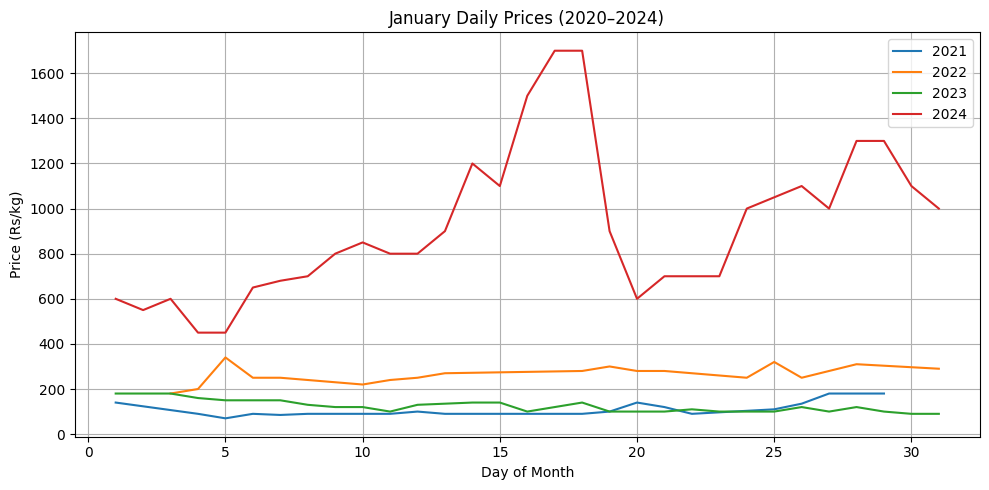

NameError: name 'pdf' is not defined

In [32]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt


# ==============================
# 2. LOAD DATASET
# ==============================
# CHANGE PATH IF NEEDED
df = pd.read_excel("../datasets/carrot_complete_growth_dataset.xlsx")

# ==============================
# 3. DATE PROCESSING
# ==============================
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day


# ==============================
# 4. RENAME PRICE COLUMN
# ==============================
df = df.rename(columns={
    "Carrot_Min_Price": "Min_Price"
})

# ==============================
# 5. FILTER REQUIRED YEARS
# ==============================
df = df[df["Year"].between(2020, 2024)]


# ==============================
# 6. MONTH NAME MAPPING
# ==============================
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}


# ==============================
# 7. CREATE 12 MONTHLY LINE PLOTS
# ==============================
for month in range(1, 13):

    plt.figure(figsize=(10, 5))

    month_data = df[df["Month"] == month]

    for year in sorted(month_data["Year"].unique()):
        year_data = month_data[month_data["Year"] == year]

        plt.plot(
            year_data["Day"],
            year_data["Min_Price"],
            label=str(year)
        )

    plt.title(f"{month_names[month]} Daily Prices (2020–2024)")
    plt.xlabel("Day of Month")
    plt.ylabel("Price (Rs/kg)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
  # SAVE CURRENT FIGURE TO PDF
    pdf.savefig()
    plt.close()

In [34]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt


# ==============================
# 2. LOAD DATASET
# ==============================
# CHANGE PATH IF NEEDED
df = pd.read_excel("../datasets/Tomato_complete_growth_dataset.xlsx")

# ==============================
# 3. DATE PROCESSING
# ==============================
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day


# ==============================
# 4. RENAME PRICE COLUMN
# ==============================
df = df.rename(columns={
    "Carrot_Min_Price": "Min_Price"
})

# ==============================
# 5. FILTER REQUIRED YEARS
# ==============================
df = df[df["Year"].between(2020, 2024)]


# ==============================
# 6. MONTH NAME MAPPING
# ==============================
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}


# ==============================
# 7. CREATE 12 MONTHLY LINE PLOTS
# ==============================
for month in range(1, 13):

    plt.figure(figsize=(10, 5))

    month_data = df[df["Month"] == month]

    for year in sorted(month_data["Year"].unique()):
        year_data = month_data[month_data["Year"] == year]

        plt.plot(
            year_data["Day"],
            year_data["Min_Price"],
            label=str(year)
        )

    plt.title(f"{month_names[month]} Daily Prices (2020–2024)")
    plt.xlabel("Day of Month")
    plt.ylabel("Price (Rs/kg)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

KeyError: 'Min_Price'

<Figure size 1000x500 with 0 Axes>

In [33]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages


# ==============================
# 2. LOAD DATASET
# ==============================
df = pd.read_excel("../datasets/carrot_complete_growth_dataset.xlsx")

df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day


# ==============================
# 3. RENAME PRICE COLUMN
# ==============================
df = df.rename(columns={
    "Carrot_Avg_Price": "Avg_Price"
})


# ==============================
# 4. FILTER YEARS
# ==============================
df = df[df["Year"].between(2020, 2024)]


# ==============================
# 5. MONTH NAME MAP
# ==============================
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}


# ==============================
# 6. CREATE PDF WITH 12 PLOTS
# ==============================
with PdfPages("Monthly_Carrot_Prices_2020_2024.pdf") as pdf:

    for month in range(1, 13):

        plt.figure(figsize=(10, 5))

        month_data = df[df["Month"] == month]

        for year in sorted(month_data["Year"].unique()):
            year_data = month_data[month_data["Year"] == year]

            plt.plot(
                year_data["Day"],
                year_data["Avg_Price"],
                label=str(year)
            )

        plt.title(f"{month_names[month]} Daily Prices (2020–2024)")
        plt.xlabel("Day of Month")
        plt.ylabel("Price (Rs/kg)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # SAVE CURRENT FIGURE TO PDF
        pdf.savefig()
        plt.close()


In [35]:
# ==============================
# 1. IMPORT LIBRARIES
# ==============================
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages


# ==============================
# 2. LOAD DATASET
# ==============================
df = pd.read_excel("../datasets/tomato_complete_growth_dataset.xlsx")

# ==============================
# 3. DATE PROCESSING
# ==============================
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day


# ==============================
# 4. RENAME PRICE COLUMN (TOMATO)
# ==============================
df = df.rename(columns={
    "Tomato_Avg_Price": "Avg_Price"
})


# ==============================
# 5. FILTER YEARS (2020–2024)
# ==============================
df = df[df["Year"].between(2020, 2024)]


# ==============================
# 6. MONTH NAME MAP
# ==============================
month_names = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May", 6: "June", 7: "July", 8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}


# ==============================
# 7. CREATE PDF WITH 12 MONTHLY PLOTS
# ==============================
with PdfPages("Monthly_Tomato_Prices_2020_2024.pdf") as pdf:

    for month in range(1, 13):

        plt.figure(figsize=(10, 5))

        month_data = df[df["Month"] == month]

        for year in sorted(month_data["Year"].unique()):
            year_data = month_data[month_data["Year"] == year]

            plt.plot(
                year_data["Day"],
                year_data["Avg_Price"],
                label=str(year)
            )

        plt.title(f"{month_names[month]} Daily Tomato Prices (2020–2024)")
        plt.xlabel("Day of Month")
        plt.ylabel("Price (Rs/kg)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()

        # SAVE CURRENT FIGURE TO PDF
        pdf.savefig()
        plt.close()
